# Week 10: K-Means Clustering

This notebook applies k-means clustering to the Diabetes Health Indicators and Alzheimer's disease datasets. The analysis will examine the elbow method, Silhouette score, feature scaling, and the role of Euclidean distance in identifying groups of similar patients.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
df_diabetes = pd.read_csv(
    "diabetes_012_health_indicators_BRFSS2015.csv"
)

df_alzheimers = pd.read_csv(
    "alzheimers_disease_data.csv"
)

# Remove the non-predictive text column
df_alzheimers = df_alzheimers.drop(
    columns=["DoctorInCharge"]
)

print("Diabetes dataset shape:", df_diabetes.shape)
print("Alzheimer's dataset shape:", df_alzheimers.shape)

Diabetes dataset shape: (253680, 22)
Alzheimer's dataset shape: (2149, 34)


In [3]:
df_diabetes.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [4]:
df_alzheimers.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,5.895077,0,0,7.119548,0,1,0,1,0,0
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,8.965106,0,1,6.481226,0,0,0,0,0,0
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,6.045039,0,0,0.014691,0,0,1,1,0,0


## Data Preparation

K-means is an unsupervised learning algorithm, so the diagnosis variables are not used to create the clusters. The diagnosis labels are saved separately and will only be used after clustering to examine whether the patient groups are associated with disease status.

PatientID is also removed from the Alzheimer's clustering features because it is only an identifier and does not represent a clinical characteristic.

In [5]:
# Check for missing values
print("Diabetes missing values:",
      df_diabetes.isnull().sum().sum())

print("Alzheimer's missing values:",
      df_alzheimers.isnull().sum().sum())

# Review diagnosis distributions
print("\nDiabetes diagnosis distribution:")
print(
    df_diabetes["Diabetes_012"]
    .value_counts()
    .sort_index()
)

print("\nAlzheimer's diagnosis distribution:")
print(
    df_alzheimers["Diagnosis"]
    .value_counts()
    .sort_index()
)

Diabetes missing values: 0
Alzheimer's missing values: 0

Diabetes diagnosis distribution:
Diabetes_012
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64

Alzheimer's diagnosis distribution:
Diagnosis
0    1389
1     760
Name: count, dtype: int64


In [6]:
# Separate diagnosis labels from clustering features
y_diabetes = df_diabetes["Diabetes_012"]
X_diabetes = df_diabetes.drop(
    columns=["Diabetes_012"]
)

y_alzheimers = df_alzheimers["Diagnosis"]
X_alzheimers = df_alzheimers.drop(
    columns=["Diagnosis", "PatientID"]
)

print("Diabetes clustering features shape:",
      X_diabetes.shape)

print("Alzheimer's clustering features shape:",
      X_alzheimers.shape)

Diabetes clustering features shape: (253680, 21)
Alzheimer's clustering features shape: (2149, 32)


Neither dataset contains missing values, so no observations need to be removed or imputed. The diabetes clustering data contains 21 health and demographic features, while the Alzheimer's clustering data contains 32 clinical, lifestyle, demographic, and symptom-related features.

The diagnosis variables were excluded so that the clusters would be formed only from similarities among patient characteristics. PatientID was also excluded because numerical differences between identification numbers have no clinical meaning.

## Feature Scaling and Distance

K-means assigns observations to clusters based on Euclidean distance from the cluster centroids. Because Euclidean distance is sensitive to the scale of the variables, features with larger numerical ranges can have more influence on the clusters than smaller or binary features.

For example, variables such as BMI, age, physical health days, MMSE score, and cholesterol measurements may have much larger ranges than variables coded as 0 or 1. Standardizing the features gives each variable a mean of approximately 0 and a standard deviation of approximately 1 so that the clustering is not driven mainly by the original measurement scale.

In [7]:
diabetes_ranges = pd.DataFrame({
    "Minimum": X_diabetes.min(),
    "Maximum": X_diabetes.max(),
    "Range": X_diabetes.max() - X_diabetes.min()
}).sort_values("Range", ascending=False)

alzheimers_ranges = pd.DataFrame({
    "Minimum": X_alzheimers.min(),
    "Maximum": X_alzheimers.max(),
    "Range": X_alzheimers.max() - X_alzheimers.min()
}).sort_values("Range", ascending=False)

print("Largest feature ranges in the diabetes dataset:")
display(diabetes_ranges.head(10))

print("Largest feature ranges in the Alzheimer's dataset:")
display(alzheimers_ranges.head(10))

Largest feature ranges in the diabetes dataset:


,Minimum,Maximum,Range
BMI,12.0,98.0,86.0
MentHlth,0.0,30.0,30.0
PhysHlth,0.0,30.0,30.0
Age,1.0,13.0,12.0
Income,1.0,8.0,7.0
Education,1.0,6.0,5.0
GenHlth,1.0,5.0,4.0
HighChol,0.0,1.0,1.0
HighBP,0.0,1.0,1.0
Smoker,0.0,1.0,1.0


Largest feature ranges in the Alzheimer's dataset:


,Minimum,Maximum,Range
CholesterolTriglycerides,50.407194,399.941862,349.534668
CholesterolTotal,150.093316,299.993352,149.900037
CholesterolLDL,50.230707,199.965665,149.734959
SystolicBP,90.000000,179.000000,89.000000
CholesterolHDL,20.003434,99.980324,79.976890
DiastolicBP,60.000000,119.000000,59.000000
Age,60.000000,90.000000,30.000000
MMSE,0.005312,29.991381,29.986068
BMI,15.008851,39.992767,24.983916
AlcoholConsumption,0.002003,19.989293,19.987290


In [8]:
diabetes_scaler = StandardScaler()
alzheimers_scaler = StandardScaler()

X_diabetes_scaled = diabetes_scaler.fit_transform(
    X_diabetes
)

X_alzheimers_scaled = alzheimers_scaler.fit_transform(
    X_alzheimers
)

X_diabetes_scaled = pd.DataFrame(
    X_diabetes_scaled,
    columns=X_diabetes.columns,
    index=X_diabetes.index
)

X_alzheimers_scaled = pd.DataFrame(
    X_alzheimers_scaled,
    columns=X_alzheimers.columns,
    index=X_alzheimers.index
)

print("Scaled diabetes feature means:")
display(
    X_diabetes_scaled.mean()
    .abs()
    .sort_values(ascending=False)
    .head()
)

print("Scaled diabetes feature standard deviations:")
display(
    X_diabetes_scaled.std()
    .sort_values(ascending=False)
    .head()
)

print("Scaled Alzheimer's feature means:")
display(
    X_alzheimers_scaled.mean()
    .abs()
    .sort_values(ascending=False)
    .head()
)

print("Scaled Alzheimer's feature standard deviations:")
display(
    X_alzheimers_scaled.std()
    .sort_values(ascending=False)
    .head()
)

Scaled diabetes feature means:


BMI          2.482754e-16
HighBP       1.797084e-16
GenHlth      1.694009e-16
CholCheck    1.272748e-16
Education    8.604491e-17
dtype: float64

Scaled diabetes feature standard deviations:


HighChol        1.000002
PhysHlth        1.000002
NoDocbcCost     1.000002
PhysActivity    1.000002
Stroke          1.000002
dtype: float64

Scaled Alzheimer's feature means:


Age                 5.819243e-16
SystolicBP          5.488604e-16
BMI                 3.967665e-16
CholesterolTotal    3.434510e-16
CholesterolLDL      2.545919e-16
dtype: float64

Scaled Alzheimer's feature standard deviations:


PersonalityChanges         1.000233
Diabetes                   1.000233
FamilyHistoryAlzheimers    1.000233
Hypertension               1.000233
DiastolicBP                1.000233
dtype: float64

The scaled feature means are effectively 0 and the standard deviations are approximately 1 for both datasets. This confirms that StandardScaler successfully placed the variables on comparable scales before applying k-means.

This step is especially important because k-means relies on Euclidean distance. Without scaling, variables such as BMI, cholesterol, blood pressure, and health-day counts would have more influence simply because they use larger numerical ranges.

## Elbow Method: Diabetes Dataset

The elbow method compares the within-cluster sum of squares, also called inertia, across different values of \(k\). Inertia decreases as more clusters are added, so the goal is to look for the point where the improvement begins to level off rather than simply choosing the largest value of \(k\).

In [9]:
k_values = range(2, 11)

diabetes_inertia = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_diabetes_scaled)
    
    diabetes_inertia.append(
        model.inertia_
    )

print(diabetes_inertia)

[4723160.31929848, 4465170.902424019, 4221461.924454042, 4009591.117745419, 3859414.9055052623, 3664258.0306671914, 3528514.7297250247, 3432067.867704072, 3271447.1208717995]


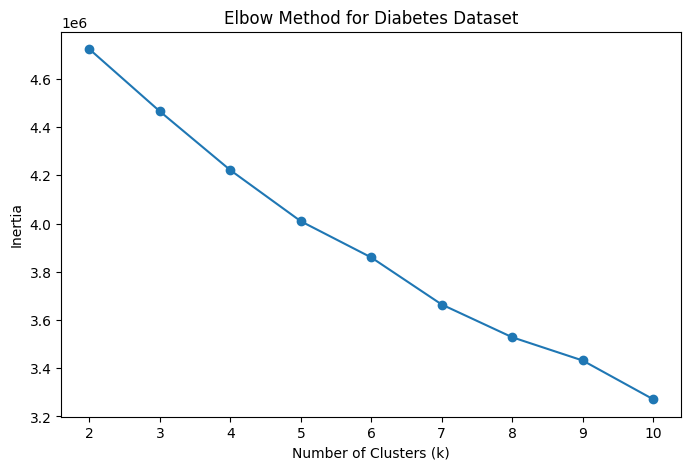

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    diabetes_inertia,
    marker="o"
)

plt.title("Elbow Method for Diabetes Dataset")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))

plt.show()

The diabetes elbow plot does not show one sharply defined elbow. Inertia decreases steadily as additional clusters are added, although the rate of improvement begins to slow somewhat around \(k=5\) to \(k=6\).

Because the elbow is not especially clear, the elbow method alone is not enough to select the final number of clusters. Silhouette scores will be used next as a second measure of cluster quality.

In [11]:
diabetes_sample = X_diabetes_scaled.sample(
    n=10000,
    random_state=42
)

diabetes_silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(diabetes_sample)

    score = silhouette_score(
        diabetes_sample,
        labels
    )

    diabetes_silhouette_scores.append(score)

print(diabetes_silhouette_scores)

[0.20533373277145742, 0.08117045750832322, 0.09150637581663615, 0.09936831695387616, 0.10598340312069565, 0.1018670648240935, 0.10237990958641185, 0.09650295145156013, 0.1158578998300893]


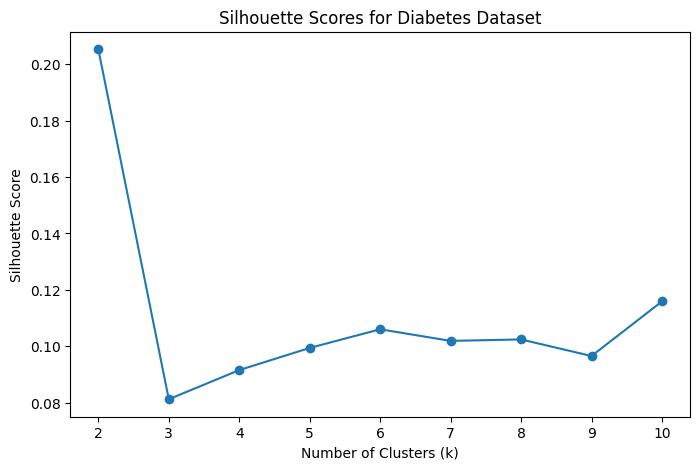

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    diabetes_silhouette_scores,
    marker="o"
)

plt.title("Silhouette Scores for Diabetes Dataset")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))

plt.show()

The Silhouette analysis provides clearer evidence than the elbow method. The highest Silhouette score is approximately 0.205 at \(k=2\), which is substantially higher than the scores for the other values of \(k\). This suggests that two clusters provide the strongest separation among the solutions tested.

However, the Silhouette score is still relatively low, indicating that the diabetes observations are not divided into strongly separated natural groups. Therefore, \(k=2\) appears to be the best choice for this dataset, but the resulting clusters should be interpreted as broad patient groupings rather than clearly distinct populations.

## Elbow Method: Alzheimer's Dataset

The same elbow method was applied to the Alzheimer's dataset to determine whether its patient characteristics show a different clustering structure. The number of clusters is evaluated separately because there is no reason to assume that the two datasets should have the same optimal value of \(k\).

In [13]:
alzheimers_inertia = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_alzheimers_scaled)

    alzheimers_inertia.append(
        model.inertia_
    )

print(alzheimers_inertia)

[66591.1696414385, 64604.8046043106, 63142.8494018696, 61759.720752065165, 60523.771130302004, 59321.63999087205, 58588.252227615776, 57650.29686679122, 57002.46642328598]


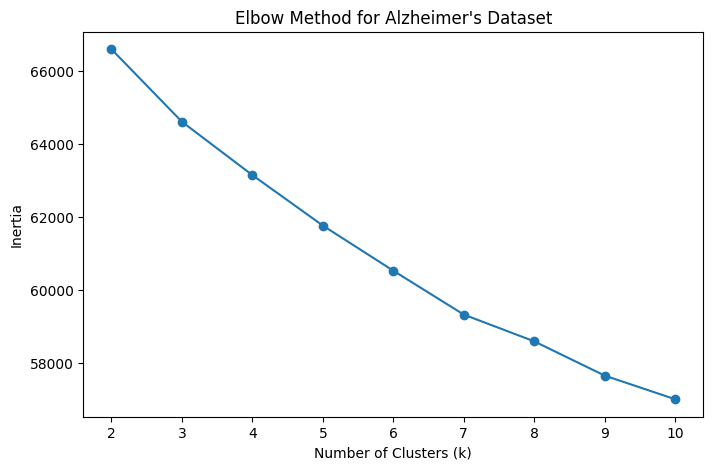

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    alzheimers_inertia,
    marker="o"
)

plt.title("Elbow Method for Alzheimer's Dataset")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))

plt.show()

## Silhouette Score: Alzheimer's Dataset

Because the elbow plot did not identify a clear value of \(k\), the Silhouette score is used as a second measure of cluster quality. A higher Silhouette score indicates that observations are more similar to others in their own cluster and more separated from observations in neighboring clusters.

In [15]:
alzheimers_silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(
        X_alzheimers_scaled
    )

    score = silhouette_score(
        X_alzheimers_scaled,
        labels
    )

    alzheimers_silhouette_scores.append(score)

print(alzheimers_silhouette_scores)

[0.0850068896677783, 0.04172631762435567, 0.03857030815097137, 0.034454218599310624, 0.03466518985132393, 0.042687218565920684, 0.03187753743702008, 0.02738062224643674, 0.025630092167858894]


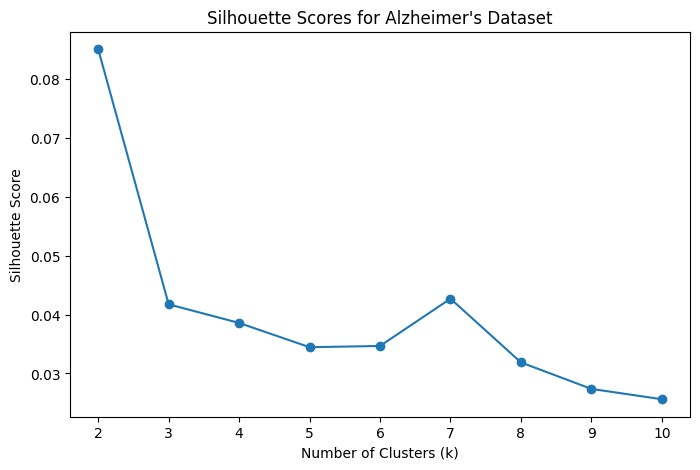

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    alzheimers_silhouette_scores,
    marker="o"
)

plt.title("Silhouette Scores for Alzheimer's Dataset")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))

plt.show()

### Cluster Selection Summary

For both datasets, the elbow plots showed gradual decreases in inertia without a clearly defined elbow. The Silhouette scores provided stronger guidance, with \(k=2\) producing the highest score for both datasets. The diabetes dataset achieved a Silhouette score of approximately 0.205, while the Alzheimer's dataset achieved only 0.085.

These results suggest that two clusters provide the best separation among the values tested, although neither dataset contains sharply separated groups. The weaker Alzheimer's score was somewhat unexpected given the stronger performance of supervised models on this dataset in earlier notebooks. This difference highlights that successful prediction of a known diagnosis does not necessarily mean that the complete feature space naturally separates into distinct groups without using the diagnosis label.

In [17]:
diabetes_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

alzheimers_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

diabetes_clusters = diabetes_kmeans.fit_predict(
    X_diabetes_scaled
)

alzheimers_clusters = alzheimers_kmeans.fit_predict(
    X_alzheimers_scaled
)

print("Diabetes cluster sizes:")
print(pd.Series(diabetes_clusters).value_counts().sort_index())

print("\nAlzheimer's cluster sizes:")
print(pd.Series(alzheimers_clusters).value_counts().sort_index())

Diabetes cluster sizes:
0     66655
1    187025
Name: count, dtype: int64

Alzheimer's cluster sizes:
0     199
1    1950
Name: count, dtype: int64


The final diabetes model produced two clusters containing 66,655 and 187,025 observations. Although the clusters are not evenly sized, both represent substantial portions of the dataset.

The Alzheimer's model produced a much more uneven split, with only 199 observations in Cluster 0 and 1,950 in Cluster 1. This imbalance is consistent with the very low Silhouette score and further suggests that the Alzheimer's feature space does not naturally separate into two similarly sized patient groups.

## Diabetes Cluster Profiles

To interpret the two diabetes clusters, the original unscaled feature values were combined with the cluster assignments. Average values for each feature were then calculated within each cluster. Using the original values makes the differences easier to interpret than using standardized values.

In [23]:
diabetes_profile = X_diabetes.copy()
diabetes_profile["Cluster"] = diabetes_clusters

diabetes_scaled_profile = X_diabetes_scaled.copy()
diabetes_scaled_profile["Cluster"] = diabetes_clusters

diabetes_scaled_means = (
    diabetes_scaled_profile
    .groupby("Cluster")
    .mean()
    .T
)

diabetes_scaled_means["Standardized Difference"] = (
    diabetes_scaled_means[0] -
    diabetes_scaled_means[1]
).abs()

top_diabetes_features = (
    diabetes_scaled_means
    .sort_values("Standardized Difference", ascending=False)
    .head(12)
    .index
)

diabetes_cluster_profile = (
    diabetes_profile
    .groupby("Cluster")[top_diabetes_features]
    .mean()
    .T
)

diabetes_cluster_profile["Standardized Difference"] = (
    diabetes_scaled_means.loc[
        top_diabetes_features,
        "Standardized Difference"
    ]
)

display(diabetes_cluster_profile)

Cluster,0,1,Standardized Difference
DiffWalk,0.575741,0.022986,1.477697
GenHlth,3.610802,2.119567,1.395666
PhysHlth,12.494667,1.300890,1.283994
Income,4.335624,6.666253,1.125286
PhysActivity,0.491456,0.851020,0.837816
Education,4.441767,5.267360,0.837509
HighBP,0.721176,0.324871,0.800724
HeartDiseaseorAttack,0.264511,0.033482,0.790961
MentHlth,7.376236,1.690950,0.766952
Stroke,0.126562,0.009924,0.591191


The two diabetes clusters show a clear difference in overall health burden. Cluster 0 has substantially more difficulty walking, poorer general health, more physically and mentally unhealthy days, and lower levels of income, education, and physical activity. This group also has higher rates of high blood pressure, heart disease, stroke, and high cholesterol and is older on average.

Cluster 1 represents a generally healthier group, with better mobility, better self-reported health, fewer unhealthy days, greater physical activity, and lower rates of several cardiovascular risk factors.

Although the overall Silhouette score indicated that the clusters are not sharply separated, the standardized cluster profiles still reveal meaningful differences in health status and socioeconomic characteristics.

### Diabetes Diagnosis by Cluster

The diabetes diagnosis was not included when forming the clusters. After clustering, the diagnosis can be compared across the two groups to determine whether the patient profiles identified by k-means are associated with different diabetes outcomes.

In [24]:
diabetes_diagnosis_by_cluster = pd.crosstab(
    diabetes_clusters,
    y_diabetes,
    normalize="index"
) * 100

diabetes_diagnosis_by_cluster.columns = [
    "No Diabetes (%)",
    "Prediabetes (%)",
    "Diabetes (%)"
]

display(
    diabetes_diagnosis_by_cluster.round(2)
)

,No Diabetes (%),Prediabetes (%),Diabetes (%)
row_0,,,
0,66.30,3.17,30.53
1,90.63,1.35,8.02


The diagnosis comparison supports the interpretation of Cluster 0 as a higher-risk health group. Diabetes prevalence is approximately 30.5% in Cluster 0 compared with only 8.0% in Cluster 1. Prediabetes is also more common in Cluster 0.

Because the diabetes diagnosis was not used to form the clusters, this result shows that k-means identified a patient group with substantially greater diabetes prevalence using only the other health and demographic characteristics. The clustering does not provide a diagnosis or a prediction, but it reveals a meaningful relationship between the unsupervised patient groups and diabetes status.

In [ ]:
alzheimers_profile = X_alzheimers.copy()
alzheimers_profile["Cluster"] = alzheimers_clusters

alzheimers_scaled_profile = X_alzheimers_scaled.copy()
alzheimers_scaled_profile["Cluster"] = alzheimers_clusters

alzheimers_scaled_means = (
    alzheimers_scaled_profile
    .groupby("Cluster")
    .mean()
    .T
)

alzheimers_scaled_means["Standardized Difference"] = (
    alzheimers_scaled_means[0] -
    alzheimers_scaled_means[1]
).abs()

top_alzheimers_features = (
    alzheimers_scaled_means
    .sort_values("Standardized Difference", ascending=False)
    .head(12)
    .index
)

alzheimers_cluster_profile = (
    alzheimers_profile
    .groupby("Cluster")[top_alzheimers_features]
    .mean()
    .T
)

alzheimers_cluster_profile["Standardized Difference"] = (
    alzheimers_scaled_means.loc[
        top_alzheimers_features,
        "Standardized Difference"
    ]
)

display(alzheimers_cluster_profile)

Cluster,0,1,Standardized Difference
HeadInjury,1.000000,0.000000,3.449789
BehavioralProblems,0.211055,0.151282,0.164380
Age,73.773869,75.024615,0.139155
FunctionalAssessment,5.393790,5.048038,0.119552
Disorientation,0.195980,0.154359,0.114048
PersonalityChanges,0.115578,0.154359,0.108381
Confusion,0.165829,0.209231,0.107468
CholesterolLDL,127.974108,123.964665,0.092476
PhysicalActivity,5.150725,4.896677,0.088936
CholesterolTotal,222.303878,225.492819,0.074977


The Alzheimer's cluster profiles are dominated by history of head injury. Every patient in Cluster 0 has a recorded head injury, while no patients in Cluster 1 do. The standardized difference for HeadInjury is approximately 3.45, much larger than the differences for any other variable.

Other characteristics, including behavioral problems, age, functional assessment, disorientation, MMSE, and cholesterol measures, differ only modestly between the clusters. This suggests that the two-cluster solution is primarily separating patients according to head injury history rather than identifying broad, well-separated clinical profiles.

This result helps explain the very small Cluster 0 and the low Silhouette score. Although \(k=2\) produced the best Silhouette score among the values tested, the clustering structure appears to be driven mainly by one relatively uncommon characteristic.

### Alzheimer's Diagnosis by Cluster

The Alzheimer's diagnosis was not used to form the clusters. The diagnosis distribution is therefore compared after clustering to determine whether the group defined largely by head injury history also differs in Alzheimer's disease prevalence.

In [22]:
alzheimers_diagnosis_by_cluster = pd.crosstab(
    alzheimers_clusters,
    y_alzheimers,
    normalize="index"
) * 100

alzheimers_diagnosis_by_cluster.columns = [
    "No Alzheimer's (%)",
    "Alzheimer's (%)"
]

display(
    alzheimers_diagnosis_by_cluster.round(2)
)

,No Alzheimer's (%),Alzheimer's (%)
row_0,,
0,67.84,32.16
1,64.31,35.69


The Alzheimer's diagnosis rates are similar across the two clusters. Alzheimer's disease is present in approximately 32.2% of Cluster 0 and 35.7% of Cluster 1.

This indicates that the head-injury-driven clustering structure does not correspond closely with Alzheimer's diagnosis. Unlike the diabetes dataset, where the higher-health-burden cluster had a much greater diabetes prevalence, the Alzheimer's clusters do not reveal a strong relationship between cluster membership and disease status.

This was an unexpected result because the Alzheimer's dataset performed well with several supervised models in earlier notebooks. The finding suggests that variables useful for predicting a known diagnosis do not necessarily produce clearly separated natural groups when the diagnosis label is removed.

## Scaling Sensitivity: Diabetes Dataset

Because k-means relies on Euclidean distance, feature scaling can materially change the clustering solution. To test how sensitive the diabetes results are to scaling, a second k-means model is fit using the original unscaled features with the same value of \(k=2\).

The scaled and unscaled solutions are compared using Silhouette score and the distribution of patients across clusters.

In [ ]:
diabetes_unscaled_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

diabetes_unscaled_clusters = diabetes_unscaled_kmeans.fit_predict(
    X_diabetes
)


sample_index = diabetes_sample.index

scaled_sample_labels = diabetes_kmeans.predict(
    X_diabetes_scaled.loc[sample_index]
)

unscaled_sample_labels = diabetes_unscaled_kmeans.predict(
    X_diabetes.loc[sample_index]
)

scaled_silhouette = silhouette_score(
    X_diabetes_scaled.loc[sample_index],
    scaled_sample_labels
)

unscaled_silhouette = silhouette_score(
    X_diabetes.loc[sample_index],
    unscaled_sample_labels
)

print("Scaled silhouette score:",
      round(scaled_silhouette, 4))

print("Unscaled silhouette score:",
      round(unscaled_silhouette, 4))

print("\nScaled cluster sizes:")
print(
    pd.Series(diabetes_clusters)
    .value_counts()
    .sort_index()
)

print("\nUnscaled cluster sizes:")
print(
    pd.Series(diabetes_unscaled_clusters)
    .value_counts()
    .sort_index()
)

Scaled silhouette score: 0.2038
Unscaled silhouette score: 0.5901

Scaled cluster sizes:
0     66655
1    187025
Name: count, dtype: int64

Unscaled cluster sizes:
0    221833
1     31847
Name: count, dtype: int64


The unscaled diabetes model produced a much higher Silhouette score of approximately 0.590 compared with 0.204 for the scaled model. However, this does not necessarily indicate that the unscaled solution is more meaningful.

Both k-means and the Silhouette score depend on Euclidean distance. Without scaling, variables with larger numerical ranges can dominate those distance calculations and create apparently well-separated clusters. The cluster sizes also changed substantially between the scaled and unscaled models, confirming that the clustering solution is sensitive to feature scale.

To determine what is driving the higher unscaled Silhouette score, the unscaled cluster profiles are examined next.

In [26]:
diabetes_unscaled_profile = X_diabetes.copy()
diabetes_unscaled_profile["Cluster"] = diabetes_unscaled_clusters

diabetes_unscaled_means = (
    diabetes_unscaled_profile
    .groupby("Cluster")
    .mean()
    .T
)

diabetes_unscaled_means["Difference"] = (
    diabetes_unscaled_means[0] -
    diabetes_unscaled_means[1]
).abs()

diabetes_unscaled_means = (
    diabetes_unscaled_means
    .sort_values("Difference", ascending=False)
)

display(diabetes_unscaled_means.head(12))

Cluster,0,1,Difference
PhysHlth,1.244314,25.123277,23.878963
MentHlth,1.962544,11.698308,9.735764
BMI,28.046228,30.723742,2.677513
Income,6.259655,4.620498,1.639157
GenHlth,2.314985,3.879486,1.564502
Age,7.943917,8.646497,0.702580
DiffWalk,0.104452,0.612428,0.507976
Education,5.107712,4.651459,0.456253
PhysActivity,0.790441,0.520426,0.270016
HighBP,0.401338,0.621691,0.220353


The unscaled cluster profiles confirm that the higher Silhouette score is largely driven by variables with larger numerical ranges. Physical health days and mental health days show the largest differences between clusters, followed by BMI. These variables contribute much more to the Euclidean distance calculation than binary indicators when the original scales are retained.

This explains why the unscaled model appears more strongly separated. However, the resulting clusters are influenced heavily by measurement scale rather than allowing all features to contribute on a comparable basis. For this reason, the standardized clustering solution remains the primary model despite its lower Silhouette score.

## Scaling Sensitivity: Alzheimer's Dataset

The Alzheimer's clustering solution is also compared with an unscaled version using the same value of \(k=2\). Because the dataset contains variables measured on very different scales, including cholesterol, blood pressure, BMI, cognitive scores, and binary symptom indicators, this comparison shows how much the clustering structure depends on standardization.

In [27]:
alzheimers_unscaled_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

alzheimers_unscaled_clusters = (
    alzheimers_unscaled_kmeans.fit_predict(
        X_alzheimers
    )
)

scaled_alzheimers_silhouette = silhouette_score(
    X_alzheimers_scaled,
    alzheimers_clusters
)

unscaled_alzheimers_silhouette = silhouette_score(
    X_alzheimers,
    alzheimers_unscaled_clusters
)

print(
    "Scaled silhouette score:",
    round(scaled_alzheimers_silhouette, 4)
)

print(
    "Unscaled silhouette score:",
    round(unscaled_alzheimers_silhouette, 4)
)

print("\nScaled cluster sizes:")
print(
    pd.Series(alzheimers_clusters)
    .value_counts()
    .sort_index()
)

print("\nUnscaled cluster sizes:")
print(
    pd.Series(alzheimers_unscaled_clusters)
    .value_counts()
    .sort_index()
)

Scaled silhouette score: 0.085
Unscaled silhouette score: 0.3909

Scaled cluster sizes:
0     199
1    1950
Name: count, dtype: int64

Unscaled cluster sizes:
0    1107
1    1042
Name: count, dtype: int64


The unscaled Alzheimer's model produced a much higher Silhouette score of approximately 0.391 compared with 0.085 for the scaled model. It also produced two nearly equal-sized clusters, unlike the highly uneven cluster sizes observed after standardization.

However, the higher unscaled Silhouette score should be interpreted cautiously. The Alzheimer's dataset contains several variables with much larger numerical ranges, especially cholesterol and blood pressure measures. Because both k-means and the Silhouette score rely on Euclidean distance, these large-scale variables may dominate the unscaled clustering solution and make the groups appear more clearly separated.

The large change in both Silhouette score and cluster size confirms that the Alzheimer's clustering solution is highly sensitive to feature scaling.

In [28]:
alzheimers_unscaled_profile = X_alzheimers.copy()
alzheimers_unscaled_profile["Cluster"] = alzheimers_unscaled_clusters

alzheimers_unscaled_means = (
    alzheimers_unscaled_profile
    .groupby("Cluster")
    .mean()
    .T
)

alzheimers_unscaled_means["Difference"] = (
    alzheimers_unscaled_means[0] -
    alzheimers_unscaled_means[1]
).abs()

alzheimers_unscaled_means = (
    alzheimers_unscaled_means
    .sort_values("Difference", ascending=False)
)

display(alzheimers_unscaled_means.head(12))

Cluster,0,1,Difference
CholesterolTriglycerides,314.224433,136.977436,177.246997
SystolicBP,133.318880,135.269674,1.950794
CholesterolTotal,224.831899,225.585947,0.754048
CholesterolHDL,59.764526,59.143765,0.620761
DiastolicBP,89.671183,90.035509,0.364325
CholesterolLDL,124.430635,124.235346,0.195289
AlcoholConsumption,10.126033,9.947448,0.178585
PhysicalActivity,5.002777,4.832476,0.170301
Age,74.839205,74.982726,0.143520
DietQuality,5.059224,4.922930,0.136294


The unscaled Alzheimer's cluster profiles show that the stronger Silhouette score is driven primarily by cholesterol triglycerides. The two clusters differ by approximately 177 points in this variable, while the differences for the remaining features are much smaller.

This confirms that the unscaled k-means solution is dominated by variables with larger numerical ranges rather than by a balanced combination of clinical, lifestyle, and symptom-related features. Although the unscaled model produces more evenly sized clusters and a higher Silhouette score, the standardized solution is more appropriate for the primary analysis because it prevents measurement scale from determining the clustering structure.

## Cluster Stability Across Random Initializations

K-means can produce different solutions depending on the initial centroid locations. To evaluate whether the selected two-cluster solutions are stable, the models are refit using several different random states while keeping the same scaled features and \(k=2\).

If the inertia and Silhouette scores remain similar across runs, that would indicate that the overall clustering structure is reasonably stable rather than being driven by a particular initialization.

In [29]:
random_states = [0, 10, 20, 30, 40]

stability_results = []

for rs in random_states:
    # Diabetes
    diabetes_model = KMeans(
        n_clusters=2,
        random_state=rs,
        n_init=10
    )

    diabetes_labels = diabetes_model.fit_predict(
        X_diabetes_scaled
    )

    diabetes_sample_labels = diabetes_model.predict(
        X_diabetes_scaled.loc[diabetes_sample.index]
    )

    diabetes_sil = silhouette_score(
        X_diabetes_scaled.loc[diabetes_sample.index],
        diabetes_sample_labels
    )

    # Alzheimer's
    alzheimers_model = KMeans(
        n_clusters=2,
        random_state=rs,
        n_init=10
    )

    alzheimers_labels = alzheimers_model.fit_predict(
        X_alzheimers_scaled
    )

    alzheimers_sil = silhouette_score(
        X_alzheimers_scaled,
        alzheimers_labels
    )

    stability_results.append({
        "Random State": rs,
        "Diabetes Inertia": diabetes_model.inertia_,
        "Diabetes Silhouette": diabetes_sil,
        "Alzheimer's Inertia": alzheimers_model.inertia_,
        "Alzheimer's Silhouette": alzheimers_sil
    })

stability_df = pd.DataFrame(stability_results)

display(stability_df.round(4))

,Random State,Diabetes Inertia,Diabetes Silhouette,Alzheimer's Inertia,Alzheimer's Silhouette
0,0,4.723162e+06,0.2039,66595.7826,0.0318
1,10,4.723150e+06,0.2026,66774.6122,0.0460
2,20,4.723160e+06,0.2038,66587.3747,0.0368
3,30,4.723158e+06,0.2020,66711.5553,0.0580
4,40,4.723157e+06,0.2037,66716.5975,0.0615


The diabetes clustering solution was highly stable across the tested random initializations. Inertia remained nearly unchanged and the Silhouette score consistently remained around 0.20. This suggests that the two-cluster diabetes solution is not strongly dependent on the initial centroid locations.

The Alzheimer's results were less stable. Silhouette scores varied from approximately 0.032 to 0.062 across the tested random states, compared with approximately 0.085 for the original model using random_state=42. This sensitivity provides additional evidence that the Alzheimer's dataset does not contain a strong or consistently defined two-cluster structure.

Together with the low Silhouette scores and the strong influence of HeadInjury on the original scaled solution, these results suggest that the Alzheimer's clusters should be interpreted cautiously. In contrast, the diabetes solution appears more reproducible across different initializations.

## Conclusion

K-means clustering produced different results across the two healthcare datasets. For both datasets, the elbow plots showed gradual decreases in inertia without a sharply defined elbow. Silhouette analysis provided clearer guidance, with \(k=2\) producing the highest score for both diabetes and Alzheimer's disease. The diabetes dataset achieved a Silhouette score of approximately 0.205, while the Alzheimer's dataset achieved only 0.085, indicating much weaker natural cluster separation for Alzheimer's.

The diabetes clusters were still meaningful despite the modest Silhouette score. One cluster reflected a higher overall health burden, including greater difficulty walking, poorer general health, more physically and mentally unhealthy days, lower income and education, less physical activity, and higher rates of cardiovascular risk factors. When the diabetes diagnosis was compared after clustering, diabetes prevalence was approximately 30.5% in this higher-burden cluster compared with only 8.0% in the healthier cluster. Because diagnosis was excluded from the clustering process, this suggests that k-means independently identified a patient group associated with substantially greater diabetes prevalence.

The Alzheimer's results were less useful for identifying broad clinical subgroups. The scaled two-cluster solution was dominated by HeadInjury, with all 199 patients in the smaller cluster having a recorded head injury. Other clinical and cognitive differences between the groups were relatively small, and Alzheimer's prevalence was similar across the clusters at approximately 32.2% and 35.7%. This was unexpected given the stronger performance of supervised models on the Alzheimer's dataset in earlier notebooks. The result suggests that features capable of predicting a known diagnosis do not necessarily form clearly separated patient groups when the diagnosis label is removed.

Feature scaling also had a major effect on both datasets. The unscaled models produced much higher Silhouette scores, approximately 0.590 for diabetes and 0.391 for Alzheimer's disease. However, the unscaled diabetes clusters were driven heavily by physical health days and mental health days, while the unscaled Alzheimer's clusters were dominated by cholesterol triglycerides. Because k-means and the Silhouette score both rely on Euclidean distance, these larger-range variables had disproportionate influence when the original scales were retained. Standardization was therefore retained for the primary analysis so that variables could contribute on a more comparable basis.

The stability analysis showed that the diabetes solution was highly consistent across different random initializations, with Silhouette scores remaining near 0.20 and inertia changing very little. The Alzheimer's solution was less stable, with noticeably greater variation in Silhouette scores across random states. This provides additional evidence that the diabetes clustering structure is more reproducible, while the Alzheimer's clustering results should be interpreted cautiously.

Overall, k-means was more informative for identifying broad health-risk patterns in the diabetes dataset than for identifying clinically meaningful Alzheimer's subgroups. The analysis also demonstrated that cluster quality cannot be evaluated from a single metric alone. Elbow plots, Silhouette scores, feature scaling, cluster profiles, diagnosis comparisons, and stability checks were all necessary to understand whether the resulting clusters were both mathematically and clinically meaningful.